Loading 'penguins' dataset...

EXECUTING ONE-WAY ANOVA
--- 0. Data Description ---
Dataset Shape: (342, 2)
Dependent Variable: body_mass_g
Independent Variable(s): species

First 5 rows:


,body_mass_g,species
0,3750.0,Adelie
1,3800.0,Adelie
2,3250.0,Adelie
4,3450.0,Adelie
5,3650.0,Adelie




--- 1. Assumption Checks ---
Normality (Shapiro-Wilk): W=0.9592, p=0.0000 -> Violated
Homogeneity (Levene's Test): W=5.1203, p=0.0064 -> Violated

--- 2. Data Visualization ---


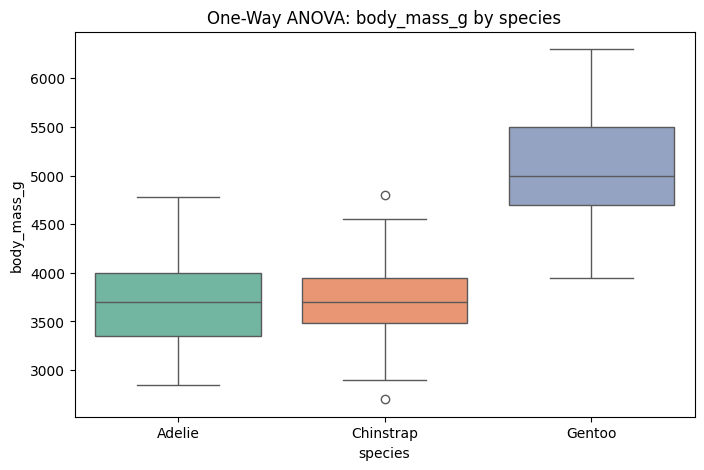


EXECUTING TWO-WAY ANOVA
--- 0. Data Description ---
Dataset Shape: (333, 3)
Dependent Variable: body_mass_g
Independent Variable(s): species & sex

First 5 rows:


,body_mass_g,species,sex
0,3750.0,Adelie,Male
1,3800.0,Adelie,Female
2,3250.0,Adelie,Female
4,3450.0,Adelie,Female
5,3650.0,Adelie,Male




--- 1. Assumption Checks ---
Normality (Shapiro-Wilk): W=0.9580, p=0.0000 -> Violated
Homogeneity (Levene's Test): W=5.1349, p=0.0064 -> Violated

--- 2. Data Visualization ---


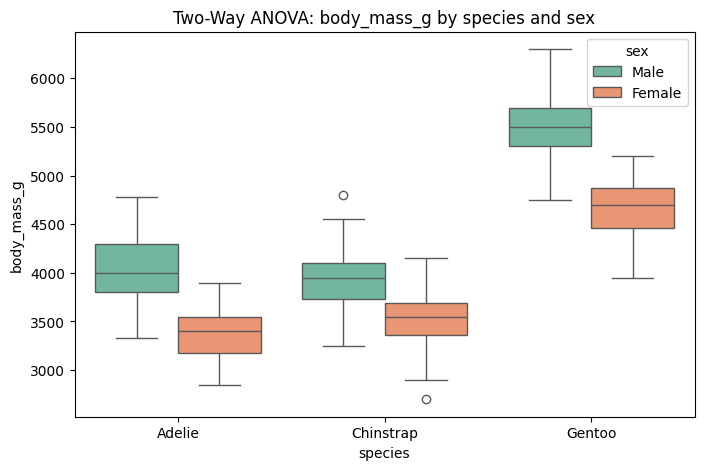

In [9]:
# CLASS ASSIGNMENT-5
# TOOLS AND METHODS OF DATA ANALYSIS - TASK : ANOVA TOOLKIT
# KARTHIK REDDY CHILKURI
# 100008159

import pandas as pd
import numpy as np
import scipy.stats as stats
#import statsmodels.api as sm
#from statsmodels.formula.api import ols
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

class ANOVAToolkit:
    def __init__(self, data, dv, between1, between2=None, alpha=0.05):
        """
        Initialize the toolkit.
        dv: Dependent Variable (continuous)
        between1: Primary grouping variable (categorical)
        between2: Secondary grouping variable for Two-Way ANOVA (optional)
        """
        # Drop missing values for the selected columns to avoid computation errors
        cols = [dv, between1] if between2 is None else [dv, between1, between2]
        self.data = data[cols].dropna()
        self.dv = dv
        self.between1 = between1
        self.between2 = between2
        self.alpha = alpha
        self.anova_type = "One-Way" if between2 is None else "Two-Way"

    def description(self):
        print(f"--- 0. Data Description ---")
        print(f"Dataset Shape: {self.data.shape}")
        print(f"Dependent Variable: {self.dv}")
        print(f"Independent Variable(s): {self.between1}" + (f" & {self.between2}" if self.between2 else ""))
        print("\nFirst 5 rows:")
        display(self.data.head())
        print("\n")

    def check_assumptions(self):
        print("--- 1. Assumption Checks ---")
        
        # 1. Normality (Shapiro-Wilk Test)
        # H0: Data is normally distributed
        stat, p_shapiro = stats.shapiro(self.data[self.dv])
        normality = "Passed" if p_shapiro > self.alpha else "Violated"
        print(f"Normality (Shapiro-Wilk): W={stat:.4f}, p={p_shapiro:.4f} -> {normality}")
        
        # 2. Homogeneity of Variances (Levene's Test)
        # H0: All input samples are from populations with equal variances
        groups = [group[self.dv].values for name, group in self.data.groupby(self.between1)]
        stat, p_levene = stats.levene(*groups)
        homogeneity = "Passed" if p_levene > self.alpha else "Violated"
        print(f"Homogeneity (Levene's Test): W={stat:.4f}, p={p_levene:.4f} -> {homogeneity}\n")

    def visualize(self):
        print("--- 2. Data Visualization ---")
        plt.figure(figsize=(8, 5))
        if self.anova_type == "One-Way":
            sns.boxplot(x=self.between1, y=self.dv, data=self.data, hue=self.between1, palette="Set2")
            plt.title(f"One-Way ANOVA: {self.dv} by {self.between1}")
        else:
            sns.boxplot(x=self.between1, y=self.dv, hue=self.between2, data=self.data, palette="Set2")
            plt.title(f"Two-Way ANOVA: {self.dv} by {self.between1} and {self.between2}")
        plt.show()

    def run_analysis(self):
        print("--- 3 & 4. Test Results & Conclusion ---")
        
        # Calculate descriptive stats
        n_total = len(self.data)
        means = self.data.groupby(self.between1)[self.dv].mean().to_dict()
        mean_str = ", ".join([f"{k}: {v:.2f}" for k, v in means.items()])
        
        # Determine max mean difference for the summary
        mean_values = list(means.values())
        mean_diff = max(mean_values) - min(mean_values)

        if self.anova_type == "One-Way":
            model = ols(f'{self.dv} ~ C({self.between1})', data=self.data).fit()
            anova_table = sm.stats.anova_lm(model, typ=2)
            
            f_stat = anova_table['F'][0]
            p_val = anova_table['PR(>F)'][0]
            df_num = anova_table['df'][0]
            df_denom = anova_table['df'][1]
            
            h0 = f"Population means of {self.dv} are equal across all groups of {self.between1}."
            ha = "At least one group mean is different."

        else:
            # Two-Way ANOVA including interaction
            formula = f'{self.dv} ~ C({self.between1}) + C({self.between2}) + C({self.between1}):C({self.between2})'
            model = ols(formula, data=self.data).fit()
            anova_table = sm.stats.anova_lm(model, typ=2)
            
            # Extracting main effect of between1 for the summary table
            f_stat = anova_table['F'][0]
            p_val = anova_table['PR(>F)'][0]
            df_num = anova_table['df'][0]
            df_denom = anova_table['df'][3] # Residual df
            
            h0 = f"No main effect of {self.between1}, no main effect of {self.between2}, and no interaction."
            ha = "There is a significant main effect or interaction."

        decision = "Reject H_0" if p_val < self.alpha else "Fail to Reject H_0"

        # Create Results Table
        results = {
            "Metric": ["Null Hypothesis (H_0)", "Alternative (H_a)", "Sample Size (N)", 
                       "Sample Means", "Max Mean Difference", "F-Statistic", 
                       "Degrees of Freedom", "p-value", "Alpha Level", "Decision"],
            "Value": [h0, ha, n_total, mean_str, f"{mean_diff:.2f}", 
                      f"{f_stat:.4f}", f"({df_num}, {df_denom})", f"{p_val:.4e}", 
                      self.alpha, decision]
        }
        
        df_results = pd.DataFrame(results)
        display(HTML(df_results.to_html(index=False)))
        print("\n")

        # Automatically Generate Conclusion
        significance = "is evidence of a significant difference" if p_val < self.alpha else "is NOT enough evidence to show a significant difference"
        
        conclusion = (f"Conclusion: Based on the {self.anova_type} ANOVA test, we {decision.lower()}. "
                      f"Because the p-value ({p_val:.4e}) is {'less' if p_val < self.alpha else 'greater'} than the "
                      f"significance level of $\\alpha = {self.alpha}$, there {significance} in {self.dv} "
                      f"across the tested groups. ")
        
        if self.anova_type == "One-Way":
            conclusion += f"This suggests that {self.between1} {'does' if p_val < self.alpha else 'does not'} have a statistically significant impact on {self.dv}."
        else:
            conclusion += f"This indicates that the interaction between {self.between1} and {self.between2} requires further post-hoc testing to understand specific group dynamics."
            
        print(conclusion)

# ==========================================
# EXECUTION SCRIPT
# ==========================================

# Load sample dataset
print("Loading 'penguins' dataset...")
df = sns.load_dataset("penguins")

# --- Test 1: One-Way ANOVA ---
print("\n" + "="*50)
print("EXECUTING ONE-WAY ANOVA")
print("="*50)
oneway_toolkit = ANOVAToolkit(data=df, dv="body_mass_g", between1="species")
oneway_toolkit.description()
oneway_toolkit.check_assumptions()
oneway_toolkit.visualize()
#oneway_toolkit.run_analysis()

# --- Test 2: Two-Way ANOVA ---
print("\n" + "="*50)
print("EXECUTING TWO-WAY ANOVA")
print("="*50)
twoway_toolkit = ANOVAToolkit(data=df, dv="body_mass_g", between1="species", between2="sex")
twoway_toolkit.description()
twoway_toolkit.check_assumptions()
twoway_toolkit.visualize()
#twoway_toolkit.run_analysis()